In [22]:
from pathlib import Path
import warnings
import math

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from results.repetition import RepetitionResults
from results.topology_results import TopologyResults

## Configuration


### Path Configuration


In [3]:
RES_PARENT_FOLDER = Path("../../results").resolve()
RES_PARENT_FOLDER.mkdir(exist_ok=True)
# BATCH_RES = RES_PARENT_FOLDER / "batch_20260204_17-30-33"
BATCH_RES = RES_PARENT_FOLDER / "batch_20260206_21-45-57"

TOPOLOGY_TO_ANALYSE = "random_20N"
TOPO_RES = BATCH_RES / TOPOLOGY_TO_ANALYSE


if not TOPO_RES.exists():
    raise FileNotFoundError(f"Results folder not found: {TOPO_RES}")

### Plot Style


In [4]:
# Time window size (in seconds) to aggregate parent changes
TIME_BIN_SIZE_S = 5.0

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")

## Main Analysis


In [5]:
print(f"Analyizing Topology: {TOPOLOGY_TO_ANALYSE}")

topo_res = TopologyResults.from_folder(TOPO_RES)

Analyizing Topology: random_20N


In [6]:
results = pd.DataFrame(
    columns=[
        "configuration",
        "seed",
        "pdr",
        "latency",
        "par_changes",
        "mean_interarrival",
        "true_mean_interarrival",
    ]
)

rows = []

# --- DATA COLLECTION PHASE ---
print("Collecting data from files...")
for channel_res in topo_res.channels:
    print(f"  > Processing config: {channel_res.channel_type}")

    for rep in channel_res.repetitions:
        repetition_data = {
            "channel": channel_res.channel_type,
            "seed": rep.id,
            "mean_interarrival": rep.compute_interarrivals()["inter_arrival"].mean(),
            "true_mean_interarrival": rep.mean_inter_arrival_time,
        }

        # PDR
        p = rep.pdr_df["delivered"].mean() if rep.pdr_df is not None else 0
        repetition_data["pdr"] = p

        # Latency
        l = rep.latency_df["latency"] if rep.latency_df is not None else None
        repetition_data["latency"] = np.mean(l) if l is not None else None

        rows.append(repetition_data)

results = pd.DataFrame(rows)

  > Processing config: ideal
  > Processing config: stable
  > Processing config: stable_mid_pl
  > Processing config: stable_high_pl
  > Processing config: lossy
  > Processing config: unstable


### Adjust NaN values in results DataFrame

In [7]:
results["pdr"] = results["pdr"].fillna(0)

Are there any NaN values in any column of the results DataFrame?

In [8]:
print(results.isna().sum())

channel                    0
seed                       0
mean_interarrival          0
true_mean_interarrival     0
pdr                        0
latency                   39
dtype: int64


In [9]:
results

,channel,seed,mean_interarrival,true_mean_interarrival,pdr,latency
0,ideal,12345,59.986209,60.0,0.984991,0.008549
1,ideal,12345_antithetic,54.289619,60.0,0.921769,0.008105
2,ideal,12346,53.066403,60.0,0.973378,0.008519
3,ideal,12346_antithetic,62.459145,60.0,0.944664,0.009136
4,ideal,12347,57.775183,60.0,0.972777,0.008012
...,...,...,...,...,...,...
595,unstable,12392,55.486419,60.0,0.000000,NaN
596,unstable,12393,54.136835,60.0,0.103448,0.017625
597,unstable,12393_antithetic,56.006149,60.0,0.191257,0.016847
598,unstable,12394,54.848554,60.0,0.321429,0.015755


## Evaluation of Correlation between IT and PDR inside a Single Run

In order to understand if it is better to use the singe values of the simulation (instead of a single metric per run) for the control variate technique, we need to evaluate if there is a correlation between the inter-arrival times and the packet delivery results.

In [10]:
rep = RepetitionResults.from_folder(TOPO_RES / "lossy" / "12385_antithetic")

interarrivals_df = rep.compute_interarrivals()


interarrivals_df["source"] = (
    interarrivals_df["node_id"]
    .dropna()
    .str.replace("Node-", "", regex=False)
    .map(lambda x: f"{int(x):04x}")
)

print(rep.pdr_df)
interarrivals_df

    source_addr  seq_num dest_addr  delivered
0          0011        1      0003          0
1          0003        1      0006          1
2          0003        2      0012          0
3          000d        1      0002          0
4          000b        1      0004          1
..          ...      ...       ...        ...
501        000b       28      000c          0
502        0007       22      000d          0
503        0009       33      000f          1
504        000b       29      0014          1
505        0014       25      0008          0

[506 rows x 4 columns]


,time,event,node_id,type,seq_num,dest,source,hops,reason,inter_arrival
21,130.233432,SEND,Node-17,DATA,1.0,0003,0011,NaN,NaN,0.000000
23,130.372490,SEND,Node-3,DATA,1.0,0006,0003,NaN,NaN,0.000000
25,131.869299,SEND,Node-3,DATA,2.0,0012,0003,NaN,NaN,1.496809
27,133.974070,SEND,Node-13,DATA,1.0,0002,000d,NaN,NaN,0.000000
29,134.517632,SEND,Node-11,DATA,1.0,0004,000b,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...
901,1797.064951,SEND,Node-11,DATA,28.0,000c,000b,NaN,NaN,5.255804
902,1798.268788,SEND,Node-7,DATA,22.0,000d,0007,NaN,NaN,75.038073
903,1799.365659,SEND,Node-9,DATA,33.0,000f,0009,NaN,NaN,128.318458
905,1799.432215,SEND,Node-11,DATA,29.0,0014,000b,NaN,NaN,2.367264


In [11]:
inter_df = interarrivals_df.rename(
    columns={
        "source": "source_addr",
        "dest": "dest_addr",
        "seq_num": "seq_num",
    }
)

pdrs_df = rep.pdr_df.rename(
    columns={
        "source_addr": "source_addr",
        "dest_addr": "dest_addr",
        "seq_num": "seq_num",
    }
)

In [12]:
inter_df["source_addr"] = inter_df["source_addr"].astype(str)
inter_df["dest_addr"] = inter_df["dest_addr"].astype(str)
inter_df["seq_num"] = inter_df["seq_num"].astype(int)

pdrs_df["source_addr"] = pdrs_df["source_addr"].astype(str)
pdrs_df["dest_addr"] = pdrs_df["dest_addr"].astype(str)
pdrs_df["seq_num"] = pdrs_df["seq_num"].astype(int)

In [13]:
joined = inter_df.merge(
    pdrs_df,
    on=["source_addr", "dest_addr", "seq_num"],
    how="outer",
    indicator=True,
    suffixes=("_send", "_pdr"),
)

In [14]:
unmatched = joined[joined["_merge"] != "both"]
print(unmatched["_merge"].value_counts())

_merge
left_only     74
right_only     0
both           0
Name: count, dtype: int64


In [15]:
missing_pdr = joined[joined["_merge"] == "left_only"]

In [16]:
missing_interarrival = joined[joined["_merge"] == "right_only"]

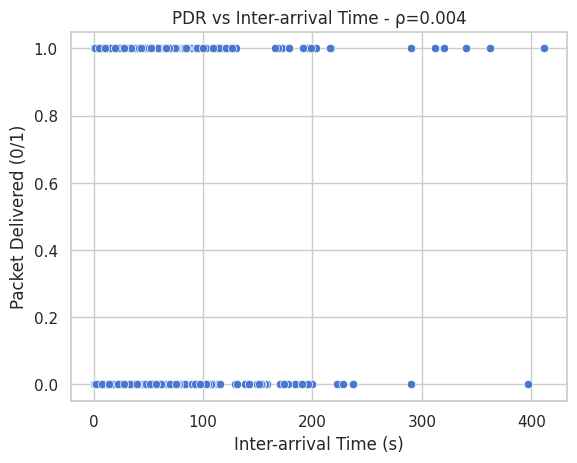

In [17]:
joined = joined[joined["_merge"] == "both"]

sns.scatterplot(
    data=joined,
    x="inter_arrival",
    y="delivered",
)
plt.xlabel("Inter-arrival Time (s)")
plt.ylabel("Packet Delivered (0/1)")
plt.title(f"PDR vs Inter-arrival Time - ρ={np.corrcoef(joined['inter_arrival'], joined['delivered'])[0,1]:.3f}")
plt.show()

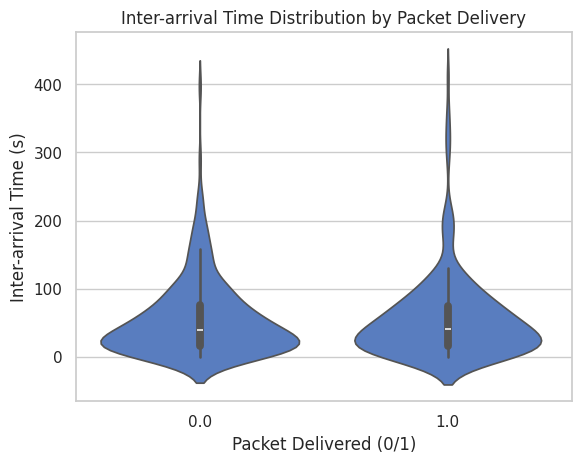

In [18]:
sns.violinplot(
    data=joined,
    x="delivered",
    y="inter_arrival",
)
plt.xlabel("Packet Delivered (0/1)")
plt.ylabel("Inter-arrival Time (s)")
plt.title("Inter-arrival Time Distribution by Packet Delivery")
plt.show()


In [19]:
def compute_optimal_beta(
    metrics: list,
    control_vars: list,
) -> float:
    """
    Computes the optimal beta coefficient for Control Variates.

    Args:
        metrics (list): List of metric values (X).
        control_vars (list): List of control variable values (Y).

    Returns:
        beta (float): Optimal beta coefficient.
    """
    X = np.array(metrics)
    Y = np.array(control_vars)
    assert len(Y) == len(X), "Metrics and control variables must have the same length."
    assert len(Y) > 1, "At least two data points are required."

    cov_XY = np.cov(X, Y, ddof=1)[0, 1]
    var_Y = np.var(Y, ddof=1)
    assert not math.isnan(cov_XY), "Covariance computation resulted in NaN."
    assert not math.isnan(var_Y), "Variance computation resulted in NaN."
    assert var_Y != 0, "Variance of control variable Y is zero."

    beta = -(cov_XY / var_Y)

    return beta


def cv_variance_reduction(
    metrics: list[float],
    control_vars: list[float],
    true_control_mean: float,
    beta: float | None = None,
) -> list[float]:
    """
    Applies Control Variates variance reduction technique.

    Args:
        metrics (list): List of metric values (X).
        control_vars (list): List of control variable values (Y).
        true_control_mean (float): True mean of the control variable (mu_Y).
        beta (float | None): Precomputed beta coefficient. If None, it will be computed.

    Returns:
        X_cv (float): Control variate adjusted metrics.
    """
    X = np.array(metrics)
    Y = np.array(control_vars)

    if len(X) != len(Y):
        raise ValueError()

    if beta is None:
        beta = compute_optimal_beta(metrics, control_vars)

    X_cv = X + beta * (Y - true_control_mean)

    return X_cv

In [49]:
CHANNEL_TO_ANALYZE = "stable"
METRIC_TO_ANALYZE = "latency"

channel_res = [c for c in topo_res.channels if c.channel_type == CHANNEL_TO_ANALYZE][0]


print(f"Channel: {channel_res.channel_type}")

Channel: stable


In [50]:
all_X_vals = []
all_Y_vals = []

for rep in channel_res.repetitions:
    if rep.latency_df is None:
        continue

    ia_df = rep.compute_interarrivals()
    ia_df[ia_df["event"] == "SEND"]
    ia_df["source_addr"] = ia_df["node_id"].map(
        lambda x: int(x.split("-")[1]).to_bytes(2, "big").hex()
    )
    ia_df["send_time"] = ia_df["time"]

    if rep.latency_df.source_addr.dtype == "int64":
        rep.latency_df.source_addr = rep.latency_df.source_addr.map(
            lambda x: x.to_bytes(2, "big").hex()
        )

    try:
        joined = ia_df.merge(
            rep.latency_df, on=["source_addr", "seq_num", "send_time"], how="right"
        ).dropna(subset="inter_arrival")

        all_X_vals += joined.latency.tolist()
        all_Y_vals += joined.inter_arrival.tolist()

    except Exception as e:
        print(f"Failed sim {rep.id}")
        raise (e)

beta = compute_optimal_beta(all_X_vals, all_Y_vals)
print(f"corr: {np.corrcoef(all_X_vals, all_Y_vals)[0,1]}")

corr: 0.010618162031793693


In [51]:
all_X_vals = []
all_Y_vals = []

for rep in channel_res.repetitions:
    if rep.pdr_df is None:
        continue

    ia_df = rep.compute_interarrivals()
    ia_df[ia_df["event"] == "SEND"]
    ia_df["source_addr"] = ia_df["node_id"].map(
        lambda x: int(x.split("-")[1]).to_bytes(2, "big").hex()
    )
    ia_df["dest_addr"] = ia_df["dest"]

    if rep.pdr_df.source_addr.dtype == "int64":
        rep.pdr_df.source_addr = rep.pdr_df.source_addr.map(
            lambda x: x.to_bytes(2, "big").hex()
        )

    try:
        joined = ia_df.merge(
            rep.pdr_df, on=["source_addr", "seq_num", "dest_addr"], how="right"
        ).dropna(subset="inter_arrival")

        all_X_vals += joined.delivered.tolist()
        all_Y_vals += joined.inter_arrival.tolist()
    

    except Exception as e:
        print(f"Failed sim {rep.id}")
        raise (e)

beta = compute_optimal_beta(all_X_vals, all_Y_vals)
print(f"corr: {np.corrcoef(all_X_vals, all_Y_vals)[0,1]}")

corr: -0.01450025015085132


In [52]:
cv_metrics = []
raw_metric = []

for rep in channel_res.repetitions:
    if rep.pdr_df is None:
        cv_metrics.append(0)
        raw_metric.append(0)
        continue

    raw_mean_pdr = np.mean(rep.pdr_df["delivered"])
    raw_metric.append(raw_mean_pdr)

    if len(rep.pdr_df) <= 2:
        cv_metrics.append(raw_mean_pdr)
        continue

    ia_df = rep.compute_interarrivals()
    ia_df[ia_df["event"] == "SEND"]
    ia_df["source_addr"] = ia_df["node_id"].map(
        lambda x: int(x.split("-")[1]).to_bytes(2, "big").hex()
    )
    ia_df["dest_addr"] = ia_df["dest"]

    if rep.pdr_df.source_addr.dtype == "int64":
        rep.pdr_df.source_addr = rep.pdr_df.source_addr.map(
            lambda x: x.to_bytes(2, "big").hex()
        )

    try:
        joined = ia_df.merge(
            rep.pdr_df, on=["source_addr", "seq_num", "dest_addr"], how="right"
        ).dropna(subset="inter_arrival")

        cv_metric = cv_variance_reduction(
            metrics=joined["delivered"],
            control_vars=joined["inter_arrival"],
            true_control_mean=rep.mean_inter_arrival_time,
            beta=beta
        )
    except Exception as e:
        print(f"Failed sim {rep.id}")
        raise (e)
    cv_metrics.append(np.mean(cv_metric))

assert len(raw_metric) == len(cv_metrics)

## Conclusions!

After trying to use the control variate technique with the inter-arrival times as the control variate, with both e2e latecy and pdr, when estimating the $\beta$ coefficient on the metric and the control variate series we found that the $\rho \approx \pm 0.04$, for the different metrics, topologies and channels. Since the theoretical variance reduction is given by $\rho^2$ we can conclude that the control variate technique is not effective in this case, since the variance reduction is in the best case of 0.16% which is negligible and is most likely going to be lost in the noise of the estimation process or even produce a variance increase instead of a reduction due to the estimation noise.

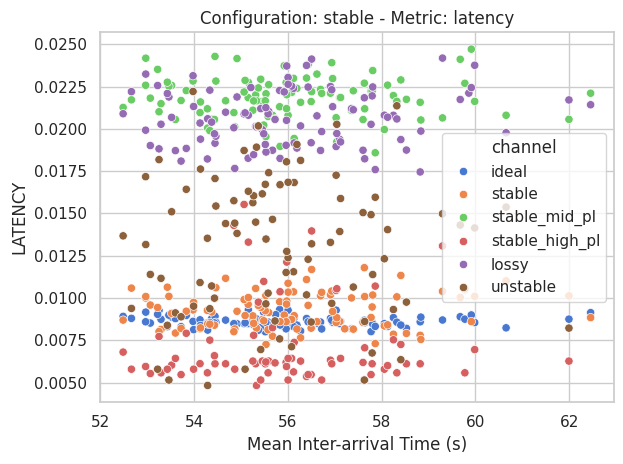

In [53]:
sns.scatterplot(data=results, x="mean_interarrival", y=METRIC_TO_ANALYZE, hue="channel")
plt.title(f"Configuration: {CHANNEL_TO_ANALYZE} - Metric: {METRIC_TO_ANALYZE}")
plt.xlabel("Mean Inter-arrival Time (s)")
plt.ylabel(METRIC_TO_ANALYZE.upper())
plt.tight_layout()
plt.show()

> [!warning]
> The following code cell is not really something significant for the analysis.

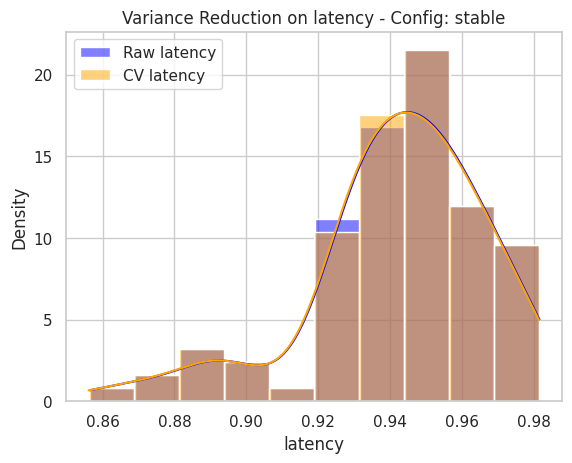

Var CV: 0.0006120375583642092
Var RW: 0.0006111318564306463


In [54]:
BINS = 10

sns.histplot(
    raw_metric,
    color="blue",
    label=f"Raw {METRIC_TO_ANALYZE}",
    kde=True,
    stat="density",
    bins=BINS,
)
sns.histplot(
    cv_metrics,
    color="orange",
    label=f"CV {METRIC_TO_ANALYZE}",
    kde=True,
    stat="density",
    bins=BINS,
)
plt.legend()
plt.title(f"Variance Reduction on {METRIC_TO_ANALYZE} - Config: {CHANNEL_TO_ANALYZE}")
plt.xlabel(METRIC_TO_ANALYZE)
plt.ylabel("Density")
plt.show()

print(f"Var CV: {np.var(cv_metrics)}")
print(f"Var RW: {np.var(raw_metric)}")